In [2]:
pip install yfinance pandas numpy matplotlib PyPortfolioOpt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns


C:\Users\Wajiz.pk\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Wajiz.pk\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

In [5]:
data = yf.download(stocks, start="2020-01-01", end="2024-01-01")["Close"]

C:\Users\Wajiz.pk\AppData\Local\Temp\ipykernel_1252\3276276467.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2024-01-01")["Close"]
C:\Users\Wajiz.pk\AppData\Roaming\Python\Python311\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  5 of 5 completed


In [9]:
returns = data.pct_change().dropna()

In [8]:
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

In [10]:
ef = EfficientFrontier(mu, S)

weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print(cleaned_weights)

OrderedDict([('AAPL', 0.30645), ('AMZN', 0.0), ('GOOGL', 0.0), ('MSFT', 0.2003), ('TSLA', 0.49325)])


In [11]:
performance = ef.portfolio_performance(verbose=True)

Expected annual return: 48.8%
Annual volatility: 44.1%
Sharpe Ratio: 1.11


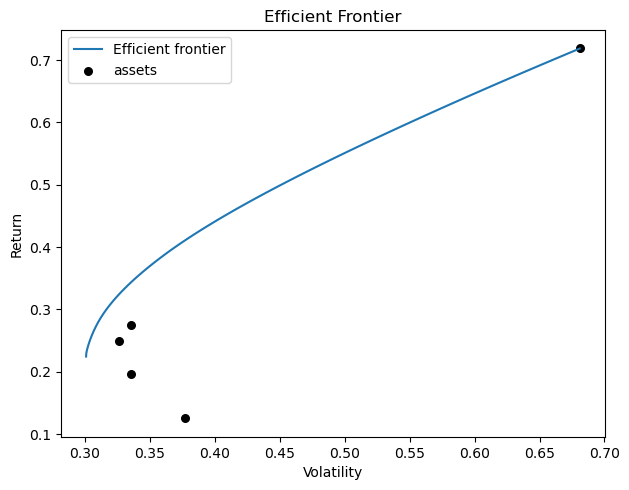

In [13]:
from pypfopt import plotting

# Create a fresh instance for plotting
ef_plot = EfficientFrontier(mu, S)

plotting.plot_efficient_frontier(ef_plot)
plt.title("Efficient Frontier")
plt.show()

In [14]:
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe(risk_free_rate=0.05)  # example 5%

In [15]:
ef.portfolio_performance(verbose=True, risk_free_rate=0.05)

Expected annual return: 55.2%
Annual volatility: 50.1%
Sharpe Ratio: 1.00


(0.5520065049313878, 0.5012688471035408, 1.001471581232525)

In [16]:
for i in range(5000):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

In [17]:
equal_weights = np.array([1/len(stocks)] * len(stocks))

In [19]:
# Equal weight portfolio performance
eq_return = np.dot(equal_weights, mu)

eq_vol = np.sqrt(np.dot(equal_weights.T, np.dot(S, equal_weights)))

eq_sharpe = eq_return / eq_vol

In [20]:
opt_return, opt_vol, opt_sharpe = ef.portfolio_performance()

C:\Users\Wajiz.pk\AppData\Roaming\Python\Python311\site-packages\pypfopt\efficient_frontier\efficient_frontier.py:441: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.
  warnings.warn(


In [21]:
comparison = pd.DataFrame({
    "Metric": ["Expected Return", "Volatility", "Sharpe Ratio"],
    "Equal Weight": [eq_return, eq_vol, eq_sharpe],
    "Optimized": [opt_return, opt_vol, opt_sharpe]
})

print(comparison)

            Metric  Equal Weight  Optimized
0  Expected Return      0.312693   0.552007
1       Volatility      0.334487   0.501269
2     Sharpe Ratio      0.934843   1.001472


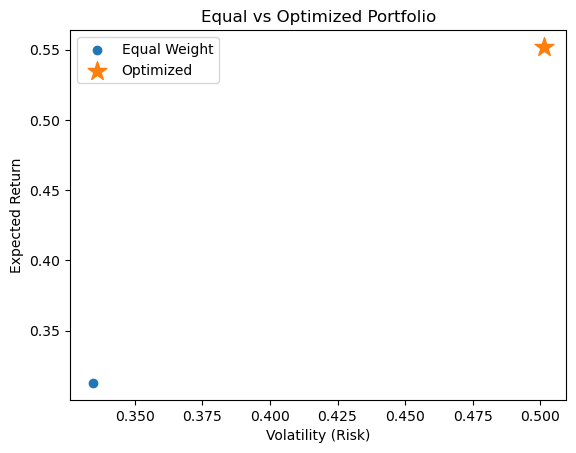

In [22]:
plt.scatter(eq_vol, eq_return, label="Equal Weight", marker="o")
plt.scatter(opt_vol, opt_return, label="Optimized", marker="*", s=200)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.legend()
plt.title("Equal vs Optimized Portfolio")
plt.show()

In [23]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

In [24]:
for i in range(num_portfolios):
    
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)   # normalize (sum = 1)

    portfolio_return = np.dot(weights, mu)
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(S, weights)))
    sharpe = portfolio_return / portfolio_vol

    results[0, i] = portfolio_return
    results[1, i] = portfolio_vol
    results[2, i] = sharpe

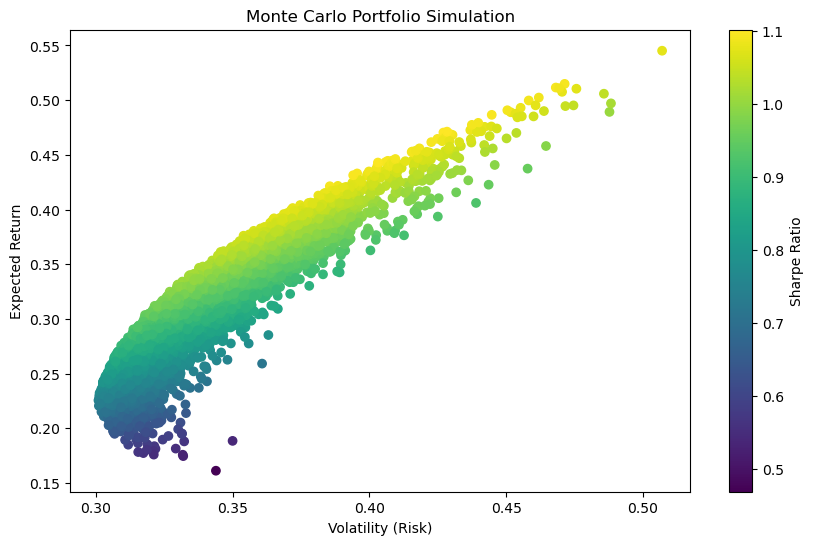

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(results[1,:], results[0,:], 
            c=results[2,:], cmap="viridis")

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.show()

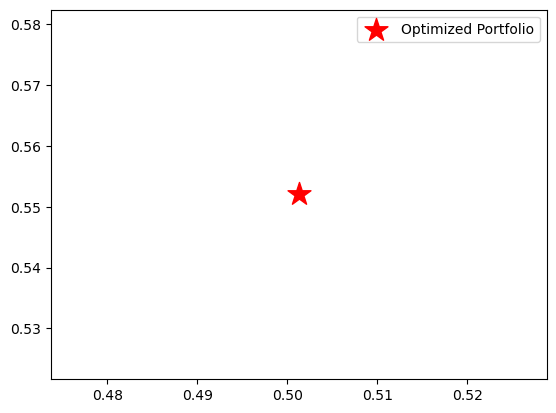

In [26]:
plt.scatter(opt_vol, opt_return, 
            color="red", marker="*", s=300, 
            label="Optimized Portfolio")

plt.legend()